# Classifying Images with Deep Convolutional Neural Networks

In [1]:
import numpy as np 
def conv1d(x,w,p=0,s=1):
    w_rot = np.array(w[::-1])
    x_padded = np.array(x)
    if p > 0:
        zero_pad = np.zeros(shape = p)
        x_padded = np.concatenate([zero_pad,x_padded, zero_pad])
    res = []
    for i in range(0, int((len(x_padded) - len(w_rot))) + 1, s):
        res.append(np.sum(x_padded[i:i+w_rot.shape[0]] * w_rot))
    return np.array(res)

x = [1, 3, 2, 4, 5, 6, 1, 3]
w = [1, 0, 3, 1, 2]
print('Conv1d Implementation:',conv1d(x, w, p=2, s=1))
print('NumPy Results:',np.convolve(x, w, mode='same'))

Conv1d Implementation: [ 5. 14. 16. 26. 24. 34. 19. 22.]
NumPy Results: [ 5 14 16 26 24 34 19 22]


In [2]:
import numpy as np
import scipy.signal
def conv2d(X, W, p=(0, 0), s=(1, 1)):
    W_rot = np.array(W)[::-1,::-1]
    X_orig = np.array(X)
    n1 = X_orig.shape[0] + 2*p[0]
    n2 = X_orig.shape[1] + 2*p[1]
    X_padded = np.zeros(shape=(n1, n2))
    X_padded[p[0]:p[0]+X_orig.shape[0],p[1]:p[1]+X_orig.shape[1]] = X_orig
    
    res = []
    
    for i in range(0, int((X_padded.shape[0] - W_rot.shape[0])/s[0])+1, s[0]):
        res.append([])
        for j in range(0, int((X_padded.shape[1] - W_rot.shape[1])/s[1])+1, s[1]):
            X_sub = X_padded[i:i+W_rot.shape[0],j:j+W_rot.shape[1]]
            res[-1].append(np.sum(X_sub * W_rot))
    return(np.array(res))

X = [[1, 3, 2, 4], [5, 6, 1, 3], [1, 2, 0, 2], [3, 4, 3, 2]]
W = [[1, 0, 3], [1, 2, 1], [0, 1, 1]]
print('Conv2d Implementation:\n',conv2d(X, W, p=(1, 1), s=(1, 1)))

print('SciPy Results:\n',scipy.signal.convolve2d(X, W, mode='same'))


Conv2d Implementation:
 [[11. 25. 32. 13.]
 [19. 25. 24. 13.]
 [13. 28. 25. 17.]
 [11. 17. 14.  9.]]
SciPy Results:
 [[11 25 32 13]
 [19 25 24 13]
 [13 28 25 17]
 [11 17 14  9]]


# Regularizing CNNs 


In [3]:
import torch.nn as nn
import torch 
loss_func = nn.BCELoss()
loss = loss_func(torch.tensor([0.9]), torch.tensor([1.0]))
l2_lambda = 0.001
conv_layer = nn.Conv2d(in_channels=3,
                        out_channels=5,
                        kernel_size=5)
l2_penalty = l2_lambda * sum([(p**2).sum() for p in conv_layer.parameters()])
loss_with_penalty = loss + l2_penalty
linear_layer = nn.Linear(10, 16)
l2_penalty = l2_lambda * sum([(p**2).sum() for p in linear_layer.parameters()])
loss_with_penalty = loss + l2_penalty

 # Loss functions for classification

In [4]:
####### Binary Cross-entropy
logits = torch.tensor([0.8])
probas = torch.sigmoid(logits)
target = torch.tensor([1.0])
bce_loss_fn = nn.BCELoss()
bce_logits_loss_fn = nn.BCEWithLogitsLoss()
print(f'BCE (w Probas): {bce_loss_fn(probas, target):.4f}')
print(f'BCE (w Logits): '      
f'{bce_logits_loss_fn(logits, target):.4f}')
####### Categorical Cross-entropy
logits = torch.tensor([[1.5, 0.8, 2.1]])
probas = torch.softmax(logits, dim=1)
target = torch.tensor([2])
cce_loss_fn = nn.NLLLoss()
cce_logits_loss_fn = nn.CrossEntropyLoss()
print(f'CCE (w Probas):{cce_logits_loss_fn(logits, target):.4f}')
print(f'CCE (w Logits): {cce_loss_fn(torch.log(probas), target):.4f}')


BCE (w Probas): 0.3711
BCE (w Logits): 0.3711
CCE (w Probas):0.5996
CCE (w Logits): 0.5996


# Implementing a deep CNN using PyTorch 

In [5]:
import torchvision
from torchvision import transforms
image_path = r"C:\Users\Aksha\Desktop\Data Science Fundamentals"
transform = transforms.Compose([transforms.ToTensor()])
mnist_dataset = torchvision.datasets.MNIST(
     root=image_path, train=True,
     transform=transform, download=True
)
from torch.utils.data import Subset
mnist_valid_dataset = Subset(mnist_dataset,
                            torch.arange(10000))
mnist_train_dataset = Subset(mnist_dataset,torch.arange( 10000, len(mnist_dataset)))
mnist_test_dataset = torchvision.datasets.MNIST(root=image_path, train=False,transform=transform, download=False)
   

In [6]:
from torch.utils.data import DataLoader
batch_size = 64
torch.manual_seed(1)
train_dl = DataLoader(mnist_train_dataset,
                      batch_size,
                      shuffle=True)
valid_dl = DataLoader(mnist_valid_dataset,
                      batch_size,
                      shuffle=False)

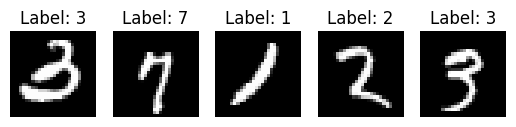

In [15]:
import matplotlib.pyplot as plt

# Get one batch from the DataLoader
images, labels = next(iter(train_dl))

# Plot first 5 images
for i in range(5):
    plt.subplot(1, 5, i+1)  # 1 row, 5 columns
    plt.imshow(images[i].squeeze(), cmap="gray")  # remove channel dim, grayscale
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.show()

In [7]:
model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(in_channels=1, out_channels=32,kernel_size=5, padding=2))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(kernel_size=2))
model.add_module('conv2',nn.Conv2d(in_channels=32, out_channels=64,kernel_size=5, padding=2))
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(kernel_size=2))

In [8]:
x = torch.ones((4, 1, 28, 28))
model(x).shape

torch.Size([4, 64, 7, 7])

In [9]:
model.add_module('flatten', nn.Flatten())
x = torch.ones((4, 1, 28, 28))
model(x).shape

torch.Size([4, 3136])

In [10]:
model.add_module('fc1', nn.Linear(3136, 1024))
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(p=0.5))
model.add_module('fc2', nn.Linear(1024, 10))

In [11]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
def train(model, num_epochs, train_dl, valid_dl):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs

    for epoch in range(num_epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            loss_hist_train[epoch] += loss.item() * y_batch.size(0)
            is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.sum()

        loss_hist_train[epoch] /= len(train_dl.dataset)
        accuracy_hist_train[epoch] /= len(train_dl.dataset)

        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in valid_dl:
                pred = model(x_batch)
                loss = loss_fn(pred, y_batch)
                loss_hist_valid[epoch] += loss.item() * y_batch.size(0)
                is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
                accuracy_hist_valid[epoch] += is_correct.sum()

        loss_hist_valid[epoch] /= len(valid_dl.dataset)
        accuracy_hist_valid[epoch] /= len(valid_dl.dataset)

        print(f'Epoch {epoch+1} accuracy: {accuracy_hist_train[epoch]:.4f} '
              f'val_accuracy: {accuracy_hist_valid[epoch]:.4f}')

    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid


torch.manual_seed(1)
num_epochs = 20
hist = train(model, num_epochs, train_dl, valid_dl)



Epoch 1 accuracy: 0.9488 val_accuracy: 0.9816
Epoch 2 accuracy: 0.9842 val_accuracy: 0.9862
Epoch 3 accuracy: 0.9896 val_accuracy: 0.9887
Epoch 4 accuracy: 0.9912 val_accuracy: 0.9885
Epoch 5 accuracy: 0.9924 val_accuracy: 0.9876
Epoch 6 accuracy: 0.9948 val_accuracy: 0.9902
Epoch 7 accuracy: 0.9960 val_accuracy: 0.9891
Epoch 8 accuracy: 0.9962 val_accuracy: 0.9899
Epoch 9 accuracy: 0.9964 val_accuracy: 0.9907
Epoch 10 accuracy: 0.9967 val_accuracy: 0.9916
Epoch 11 accuracy: 0.9969 val_accuracy: 0.9900
Epoch 12 accuracy: 0.9973 val_accuracy: 0.9903
Epoch 13 accuracy: 0.9971 val_accuracy: 0.9912
Epoch 14 accuracy: 0.9975 val_accuracy: 0.9905
Epoch 15 accuracy: 0.9984 val_accuracy: 0.9914
Epoch 16 accuracy: 0.9979 val_accuracy: 0.9912
Epoch 17 accuracy: 0.9981 val_accuracy: 0.9907
Epoch 18 accuracy: 0.9980 val_accuracy: 0.9915
Epoch 19 accuracy: 0.9988 val_accuracy: 0.9886
Epoch 20 accuracy: 0.9976 val_accuracy: 0.9890


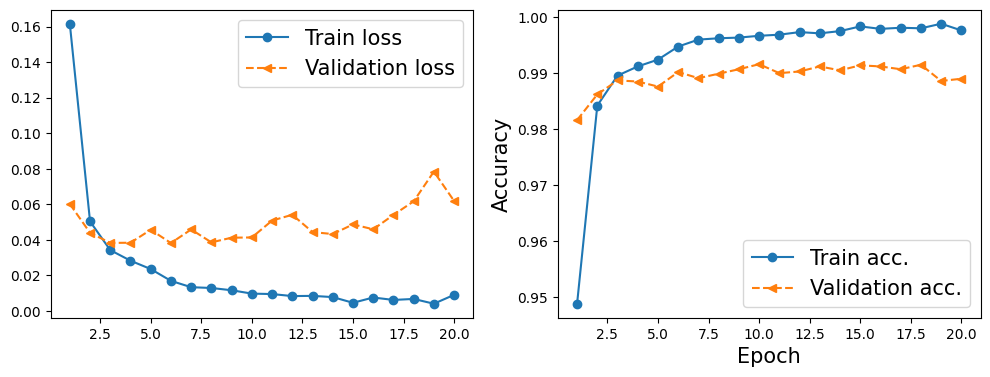

In [13]:
import matplotlib.pyplot as plt
import numpy as np

x_arr = np.arange(len(hist[0])) + 1
fig = plt.figure(figsize=(12, 4))

ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist[0], '-o', label='Train loss')
ax.plot(x_arr, hist[1], '--<', label='Validation loss')
ax.legend(fontsize=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist[2], '-o', label='Train acc.')
ax.plot(x_arr, hist[3], '--<', label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Accuracy', size=15)

plt.show()



Test accuracy: 0.9905


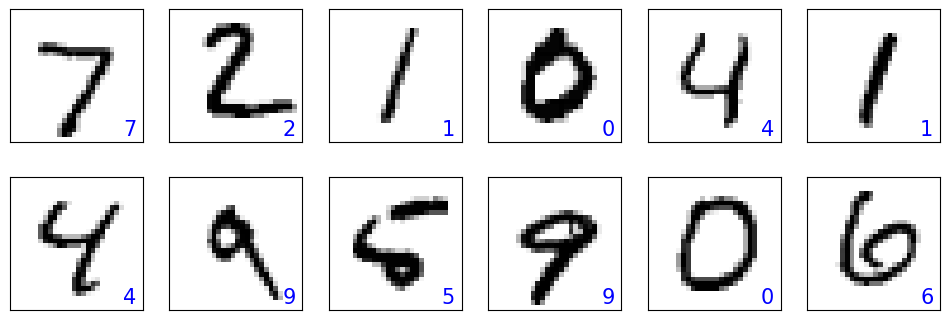

In [14]:
pred = model(mnist_test_dataset.data.unsqueeze(1) / 255.)
is_correct = (torch.argmax(pred, dim=1) == mnist_test_dataset.targets).float()
print(f'Test accuracy: {is_correct.mean():.4f}')

fig = plt.figure(figsize=(12, 4))
for i in range(12):
    ax = fig.add_subplot(2, 6, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    img = mnist_test_dataset[i][0][0, :, :]
    pred = model(img.unsqueeze(0).unsqueeze(1))
    y_pred = torch.argmax(pred)
    ax.imshow(img, cmap='gray_r')
    ax.text(0.9, 0.1, y_pred.item(), size=15, color='blue',
            horizontalalignment='center',
            verticalalignment='center',
            transform=ax.transAxes)

plt.show()

# Smile classification from face images using a CNN

In [18]:
image_path = r"C:\Users\Aksha\Desktop\Data Science Fundamentals"
celeba_train_dataset = torchvision.datasets.CelebA(
                                                    image_path, split='train',
                                                    target_type='attr', download=True)
celeba_valid_dataset = torchvision.datasets.CelebA(
                                                     image_path, split='valid',
                                                    target_type='attr', download=True
                                                     )
celeba_test_dataset = torchvision.datasets.CelebA(
                                                    image_path, split='test',
                                                    target_type='attr', download=True
                                                    )

print('Train set:', len(celeba_train_dataset))
print('Validation set:', len(celeba_valid_dataset))
print('Test set:', len(celeba_test_dataset))

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Train set: 162770
Validation set: 19867
Test set: 19962


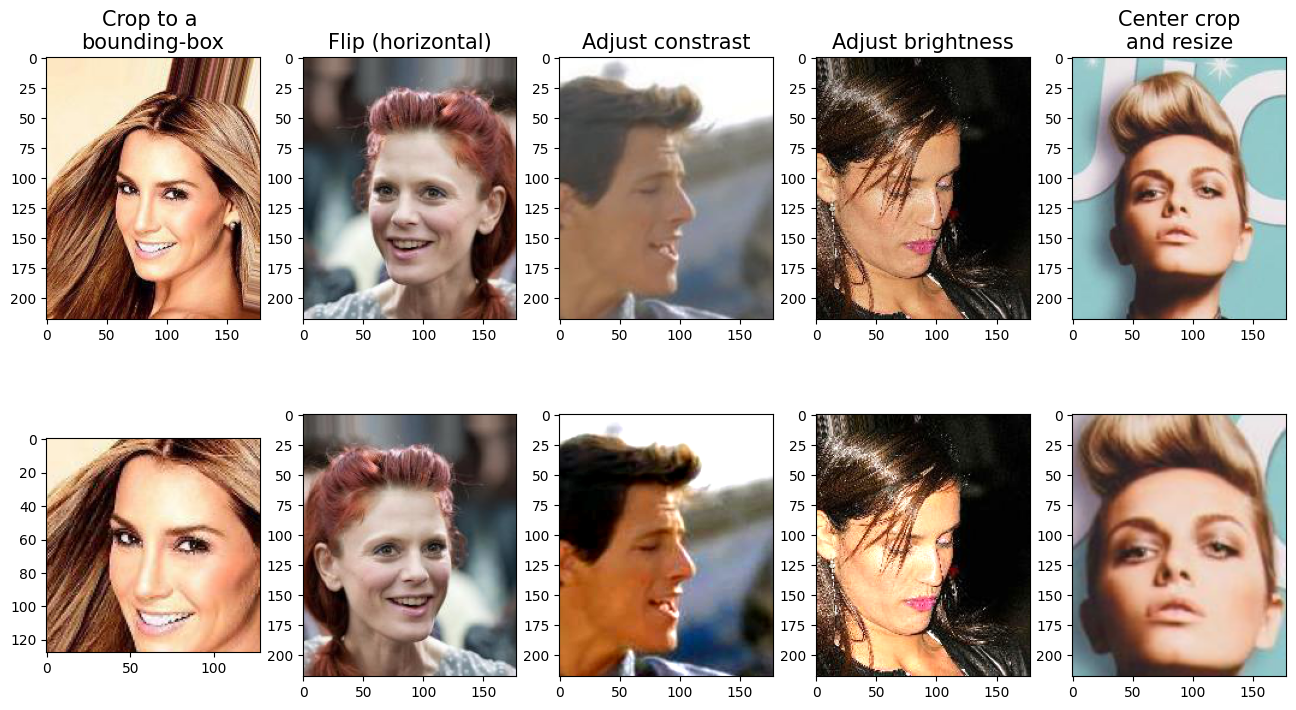

In [23]:
fig = plt.figure(figsize=(16, 8.5))
## Column 1: cropping to a bounding-box
ax = fig.add_subplot(2, 5, 1)
img, attr = celeba_train_dataset[0]
ax.set_title('Crop to a \nbounding-box', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 6)
img_cropped = transforms.functional.crop(img, 50, 20, 128, 128)
ax.imshow(img_cropped)


## Column 2: flipping (horizontally)
ax = fig.add_subplot(2, 5, 2)
img, attr = celeba_train_dataset[1]
ax.set_title('Flip (horizontal)', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 7)
img_flipped = transforms.functional.hflip(img)
ax.imshow(img_flipped)

## Column 3: adjust contrast
ax = fig.add_subplot(2, 5, 3)
img, attr = celeba_train_dataset[2]
ax.set_title('Adjust constrast', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 8)
img_adj_contrast = transforms.functional.adjust_contrast(img, contrast_factor=2)
ax.imshow(img_adj_contrast)

## Column 4: adjust brightness
ax = fig.add_subplot(2, 5, 4)
img, attr = celeba_train_dataset[3]
ax.set_title('Adjust brightness', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 9)
img_adj_brightness = transforms.functional.adjust_brightness(img, brightness_factor=1.3)
ax.imshow(img_adj_brightness)

## Column 5: cropping from image center
ax = fig.add_subplot(2, 5, 5)
img, attr = celeba_train_dataset[4]
ax.set_title('Center crop\nand resize', size=15)
ax.imshow(img)
ax = fig.add_subplot(2, 5, 10)
img_center_crop = transforms.functional.center_crop(img, [0.7*218, 0.7*178])
img_resized = transforms.functional.resize(img_center_crop, size=(218, 178))
ax.imshow(img_resized)
plt.show()

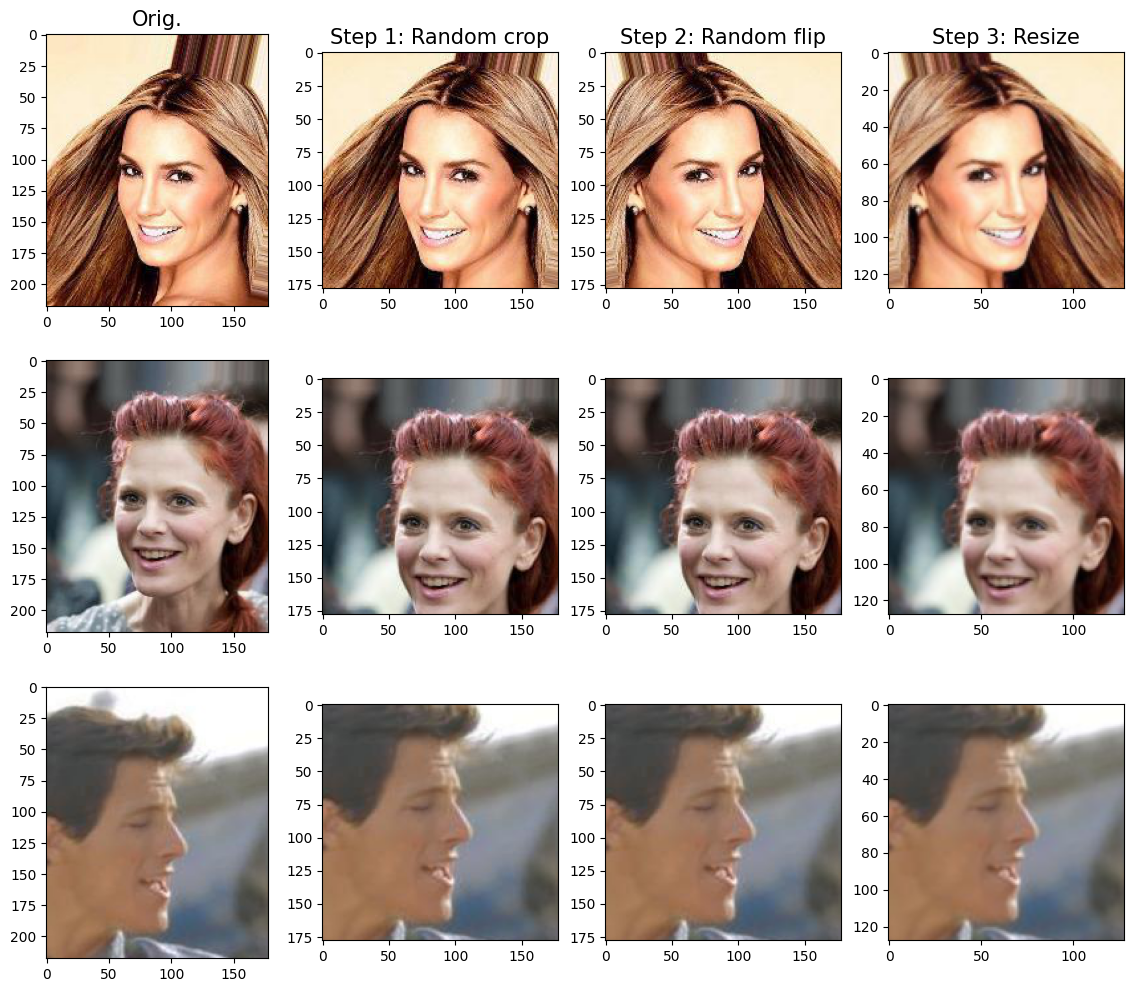

In [24]:
torch.manual_seed(1)
fig = plt.figure(figsize=(14, 12))
for i, (img, attr) in enumerate(celeba_train_dataset):
    ax = fig.add_subplot(3, 4, i*4+1)
    ax.imshow(img)
    if i == 0:
        ax.set_title('Orig.', size=15)
    ax = fig.add_subplot(3, 4, i*4+2)
    img_transform = transforms.Compose([transforms.RandomCrop([178, 178])])
    img_cropped = img_transform(img)
    ax.imshow(img_cropped)
    if i == 0:
        ax.set_title('Step 1: Random crop', size=15)
    ax = fig.add_subplot(3, 4, i*4+3)
    img_transform = transforms.Compose([transforms.RandomHorizontalFlip()])
    img_flip = img_transform(img_cropped)
    ax.imshow(img_flip)
    if i == 0:
        ax.set_title('Step 2: Random flip', size=15)       
    ax = fig.add_subplot(3, 4, i*4+4)
    img_resized = transforms.functional.resize(img_flip, size=(128, 128))
    ax.imshow(img_resized)
    if i == 0:
        ax.set_title('Step 3: Resize', size=15)
    if i == 2:     
        break
plt.show()

In [ ]:
get_smile = lambda attr: attr[18]

<function __main__.<lambda>(attr)>

In [27]:
transform_train = transforms.Compose([
                                        transforms.RandomCrop([178, 178]),
                                        transforms.RandomHorizontalFlip(),
                                        transforms.Resize([64, 64]),
                                        transforms.ToTensor(),
                                        ])
transform = transforms.Compose([
                                    transforms.CenterCrop([178, 178]),
                                    transforms.Resize([64, 64]),
                                    transforms.ToTensor(),
                                ])

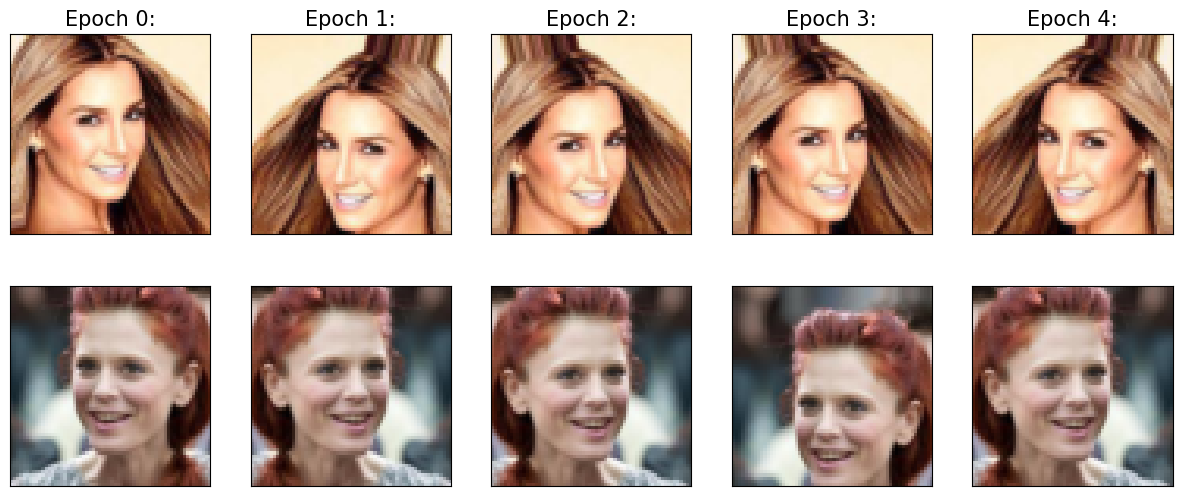

In [28]:
celeba_train_dataset = torchvision.datasets.CelebA(
    image_path, 
    split='train',
    target_type='attr', 
    download=False,
    transform=transform_train, 
    target_transform=get_smile
)

torch.manual_seed(1)
data_loader = DataLoader(celeba_train_dataset, batch_size=2)

fig = plt.figure(figsize=(15, 6))
num_epochs = 5

for j in range(num_epochs):
    img_batch, label_batch = next(iter(data_loader))
    
    img = img_batch[0]
    ax = fig.add_subplot(2, 5, j + 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Epoch {j}:', size=15)
    ax.imshow(img.permute(1, 2, 0))
    
    img = img_batch[1]
    ax = fig.add_subplot(2, 5, j + 6)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(img.permute(1, 2, 0))

plt.show()

In [29]:
celeba_valid_dataset = torchvision.datasets.CelebA(
                                                    image_path, split='valid',
                                                    target_type='attr', download=False,
                                                    transform=transform, target_transform=get_smile
                                                )
celeba_test_dataset = torchvision.datasets.CelebA(
                                                    image_path, split='test',
                                                    target_type='attr', download=False,
                                                    transform=transform, target_transform=get_smile
                                                )

from torch.utils.data import Subset
celeba_train_dataset = Subset(celeba_train_dataset, torch.arange(16000))
celeba_valid_dataset = Subset(celeba_valid_dataset, torch.arange(1000))
print('Train set:', len(celeba_train_dataset))
print('Validation set:', len(celeba_valid_dataset))


batch_size = 32
torch.manual_seed(1)
train_dl = DataLoader(celeba_train_dataset,
                      batch_size, shuffle=True)
valid_dl = DataLoader(celeba_valid_dataset,
                      batch_size, shuffle=False)
test_dl = DataLoader(celeba_test_dataset,
                     batch_size, shuffle=False)

Train set: 16000
Validation set: 1000


In [30]:
model = nn.Sequential()

# First convolution block
model.add_module(
    'conv1',
    nn.Conv2d(
        in_channels=3, out_channels=32,
        kernel_size=3, padding=1
    )
)
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(kernel_size=2))
model.add_module('dropout1', nn.Dropout(p=0.5))

# Second convolution block
model.add_module(
    'conv2',
    nn.Conv2d(
        in_channels=32, out_channels=64,
        kernel_size=3, padding=1
    )
)
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(kernel_size=2))
model.add_module('dropout2', nn.Dropout(p=0.5))

# Third convolution block
model.add_module(
    'conv3',
    nn.Conv2d(
        in_channels=64, out_channels=128,
        kernel_size=3, padding=1
    )
)
model.add_module('relu3', nn.ReLU())
model.add_module('pool3', nn.MaxPool2d(kernel_size=2))

# Fourth convolution block
model.add_module(
    'conv4',
    nn.Conv2d(
        in_channels=128, out_channels=256,
        kernel_size=3, padding=1
    )
)
model.add_module('relu4', nn.ReLU())

In [31]:
x = torch.ones((4, 3, 64, 64))
model(x).shape

torch.Size([4, 256, 8, 8])

In [32]:
model.add_module('pool4', nn.AvgPool2d(kernel_size=8))
model.add_module('flatten', nn.Flatten())
x = torch.ones((4, 3, 64, 64))
model(x).shape

torch.Size([4, 256])

In [33]:
model.add_module('fc', nn.Linear(256, 1))
model.add_module('sigmoid', nn.Sigmoid())
x = torch.ones((4, 3, 64, 64))
model(x).shape
model

Sequential(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.5, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu4): ReLU()
  (pool4): AvgPool2d(kernel_size=8, stride=8, padding=0)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [35]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
def train(model, num_epochs, train_dl, valid_dl):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch.float())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            loss_hist_train[epoch] += loss.item() * y_batch.size(0)
            is_correct = ((pred >= 0.5).float() == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.sum()

        loss_hist_train[epoch] /= len(train_dl.dataset)
        accuracy_hist_train[epoch] /= len(train_dl.dataset)

        # Validation phase
        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in valid_dl:
                pred = model(x_batch)[:, 0]
                loss = loss_fn(pred, y_batch.float())
                loss_hist_valid[epoch] += loss.item() * y_batch.size(0)
                is_correct = ((pred >= 0.5).float() == y_batch).float()
                accuracy_hist_valid[epoch] += is_correct.sum()

        loss_hist_valid[epoch] /= len(valid_dl.dataset)
        accuracy_hist_valid[epoch] /= len(valid_dl.dataset)

        print(f'Epoch {epoch+1} accuracy: '
              f'{accuracy_hist_train[epoch]:.4f} val_accuracy: '
              f'{accuracy_hist_valid[epoch]:.4f}')

    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid


In [36]:
torch.manual_seed(1)
num_epochs = 30
hist = train(model, num_epochs, train_dl, valid_dl)

Epoch 1 accuracy: 0.6243 val_accuracy: 0.7010
Epoch 2 accuracy: 0.7014 val_accuracy: 0.7210
Epoch 3 accuracy: 0.7188 val_accuracy: 0.7570
Epoch 4 accuracy: 0.7306 val_accuracy: 0.7350
Epoch 5 accuracy: 0.7440 val_accuracy: 0.7730
Epoch 6 accuracy: 0.7513 val_accuracy: 0.7790
Epoch 7 accuracy: 0.7634 val_accuracy: 0.7700
Epoch 8 accuracy: 0.7717 val_accuracy: 0.8030
Epoch 9 accuracy: 0.7836 val_accuracy: 0.8020
Epoch 10 accuracy: 0.7898 val_accuracy: 0.8030
Epoch 11 accuracy: 0.7962 val_accuracy: 0.8280
Epoch 12 accuracy: 0.8136 val_accuracy: 0.8440
Epoch 13 accuracy: 0.8279 val_accuracy: 0.8450
Epoch 14 accuracy: 0.8353 val_accuracy: 0.8480
Epoch 15 accuracy: 0.8381 val_accuracy: 0.8640
Epoch 16 accuracy: 0.8481 val_accuracy: 0.8590
Epoch 17 accuracy: 0.8556 val_accuracy: 0.8730
Epoch 18 accuracy: 0.8572 val_accuracy: 0.8640
Epoch 19 accuracy: 0.8556 val_accuracy: 0.8770
Epoch 20 accuracy: 0.8584 val_accuracy: 0.8690
Epoch 21 accuracy: 0.8632 val_accuracy: 0.8510
Epoch 22 accuracy: 0.8

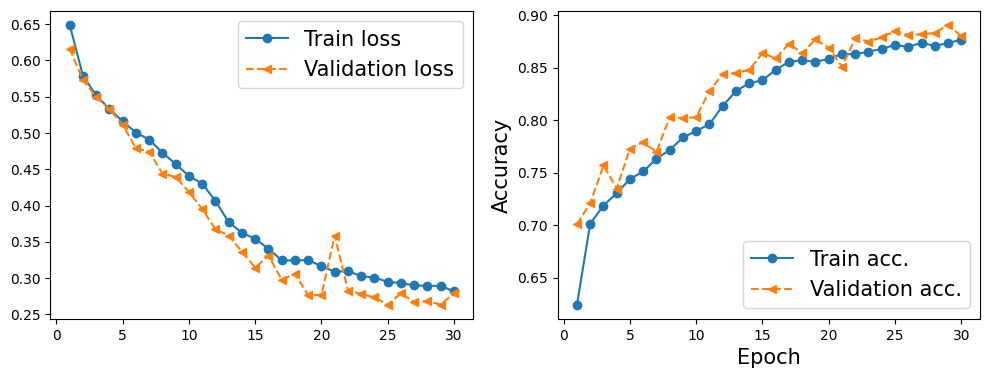

In [37]:
x_arr = np.arange(len(hist[0])) + 1
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist[0], '-o', label='Train loss')
ax.plot(x_arr, hist[1], '--<', label='Validation loss')
ax.legend(fontsize=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist[2], '-o', label='Train acc.')
ax.plot(x_arr, hist[3], '--<',
        label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Accuracy', size=15)
plt.show()

In [38]:
accuracy_test = 0
model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_dl:
        pred = model(x_batch)[:, 0]
        is_correct = ((pred>=0.5).float() == y_batch).float()
        accuracy_test += is_correct.sum()
accuracy_test /= len(test_dl.dataset)
print(f'Test accuracy: {accuracy_test:.4f}')

Test accuracy: 0.8669


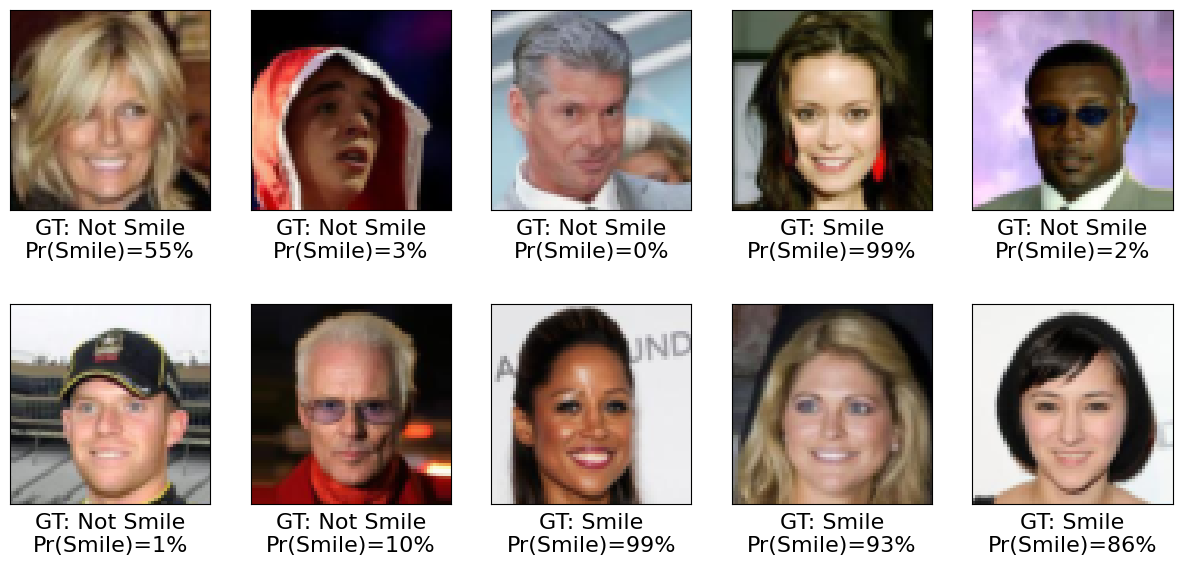

In [40]:
pred = model(x_batch)[:, 0] * 100

fig = plt.figure(figsize=(15, 7))

for j in range(10, 20):
    ax = fig.add_subplot(2, 5, j - 10 + 1)
    ax.set_xticks([])
    ax.set_yticks([])

    # Display image
    ax.imshow(x_batch[j].permute(1, 2, 0))

    # Determine label
    if y_batch[j] == 1:
        label = 'Smile'
    else:
        label = 'Not Smile'

    # Add prediction text
    ax.text(
        0.5, -0.15,
        f'GT: {label}\nPr(Smile)={pred[j]:.0f}%',
        size=16,
        ha='center',
        va='center',
        transform=ax.transAxes
    )

plt.show()